В цьому ноутбуці відбуваєтся перевірка одного активу на рандомних відрізках часу. Метою є перевірка чи отримані загальні результати релевантні для різних режимів ринку

In [1]:
import os
os.chdir("..")

In [2]:
import pandas as pd
import numpy as np

import random
import yaml

from app import BacktestDCA
from ploter import ploter

# stocks

In [3]:
df_stocks = pd.read_csv("data/test_crypto.csv", index_col=0, parse_dates=True)
df_stocks.dropna(inplace=True, axis=1)
df_stocks

,BTC,ETH,XRP,USDT,BCH,LTC,EOS,BNB,BSV,XLM,...,MKR,ONT,DOGE,VET,BAT,OMG,SNX,ZRX,ICX,QTUM
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-13,10214.379883,268.099243,0.326706,0.998579,474.317993,80.403427,5.341575,25.440100,359.041138,0.082655,...,625.763184,1.021036,0.003026,0.008026,0.295389,1.280141,0.932967,0.320865,0.394342,2.842507
2020-02-14,10312.116211,284.217499,0.334822,1.000114,491.160645,82.990349,5.361947,26.296959,360.390015,0.085796,...,638.993713,1.071109,0.003130,0.008323,0.311020,1.370907,0.992797,0.345264,0.400229,3.015611
2020-02-15,9889.424805,264.728577,0.306236,0.999128,437.664948,76.513245,4.743118,24.149651,310.077820,0.079246,...,607.280212,0.957589,0.002920,0.007440,0.280342,1.289413,0.949770,0.317226,0.360399,2.677241
2020-02-16,9934.433594,259.894714,0.295034,0.999272,415.940643,75.152588,4.412250,23.466389,285.867523,0.075079,...,634.711975,0.909603,0.002774,0.007133,0.264260,1.190897,0.945258,0.299002,0.348740,2.511193
2020-02-17,9690.142578,266.363434,0.286572,0.998474,409.344574,73.251305,4.346360,23.551378,309.441620,0.071851,...,614.943604,0.878514,0.002712,0.006756,0.266563,1.169630,1.011205,0.291352,0.344687,2.499368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-31,68233.312500,2104.708252,1.340259,0.999024,466.334564,53.917908,0.075516,617.049194,13.852106,0.167265,...,1740.242554,0.083272,0.092208,0.006763,0.096228,0.054769,0.287147,0.103136,0.034007,0.887649
2026-04-01,68078.554688,2138.737061,1.347766,0.999800,454.311554,53.805855,0.078632,610.622986,14.003111,0.169253,...,1785.234497,0.112436,0.092191,0.006885,0.099325,0.055448,0.281543,0.104537,0.035458,0.930321
2026-04-02,66888.570312,2056.852539,1.318691,0.999892,444.056213,52.260174,0.076542,583.136841,14.614312,0.163015,...,1750.205811,0.108114,0.090374,0.006740,0.094341,0.053399,0.278585,0.102121,0.035270,0.879604


In [4]:
target_asset = "BSV"
asset_prices = df_stocks[target_asset].dropna()

n_periods = 10
sequence_length = 365 * 3

periods = []
for i in range(n_periods):
    start = random.randint(0, len(asset_prices) - sequence_length)
    period_prices = asset_prices.iloc[start:start + sequence_length]
    periods.append({
        "period_id": i + 1,
        "start": period_prices.index.min(),
        "end": period_prices.index.max(),
        "prices": period_prices,
    })

In [5]:
pd.DataFrame(
    [{"period": p["period_id"], "start": p["start"], "end": p["end"], "days": len(p["prices"])} for p in periods]
 )

,period,start,end,days
0,1,2020-08-18,2023-08-17,1095
1,2,2021-10-18,2024-10-16,1095
2,3,2022-07-02,2025-06-30,1095
3,4,2020-08-27,2023-08-26,1095
4,5,2022-07-06,2025-07-04,1095
5,6,2020-04-26,2023-04-25,1095
6,7,2020-02-19,2023-02-17,1095
7,8,2021-09-01,2024-08-30,1095
8,9,2022-12-10,2025-12-08,1095
9,10,2020-03-07,2023-03-06,1095


In [6]:
strategy = {
    "buy_amount": 10,
}

17:25:05 - cmdstanpy - INFO - Chain [1] start processing
17:25:06 - cmdstanpy - INFO - Chain [1] done processing


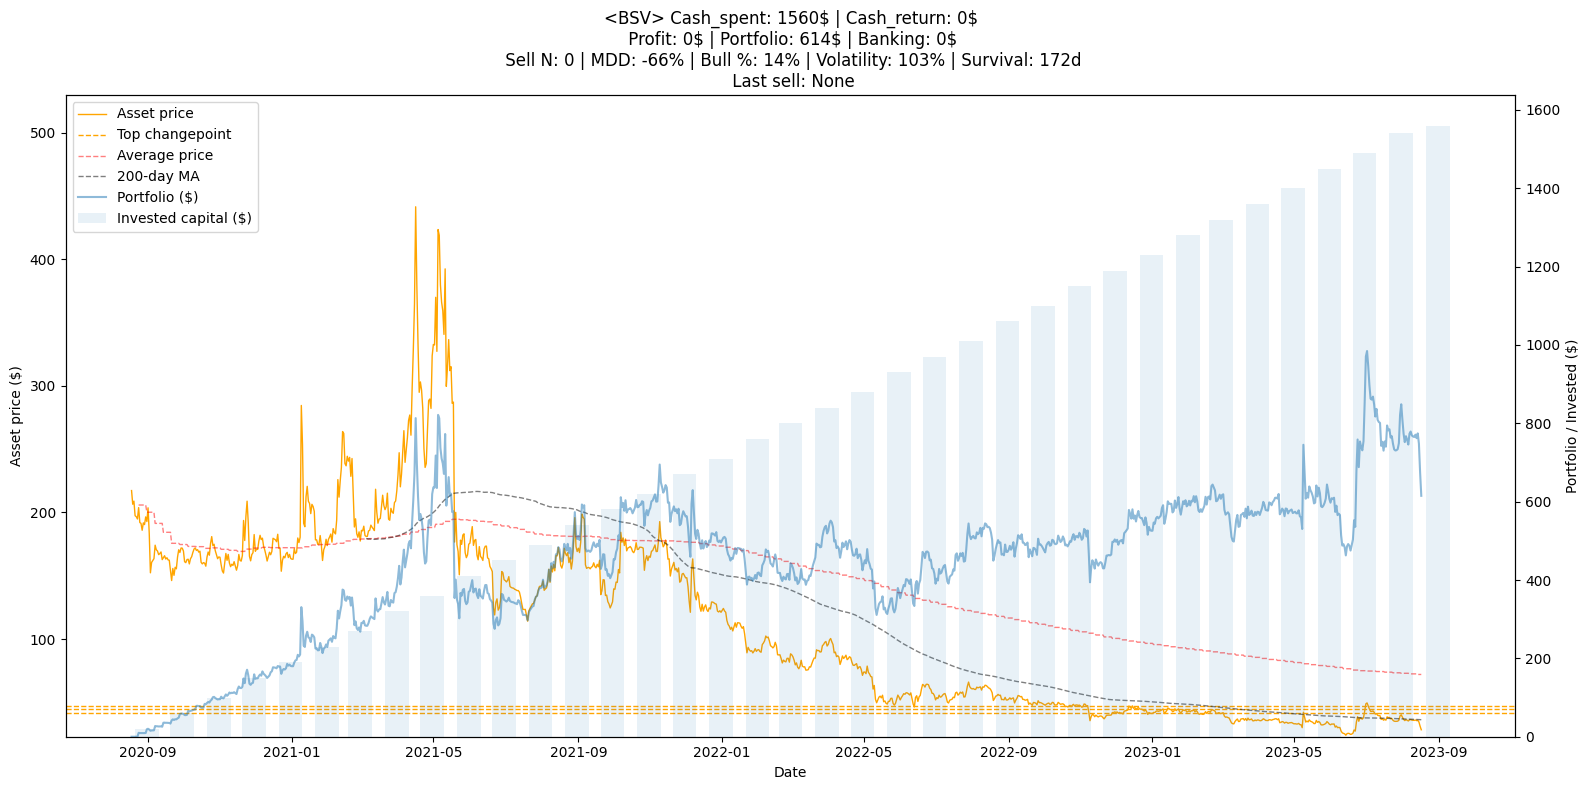

17:25:07 - cmdstanpy - INFO - Chain [1] start processing
17:25:07 - cmdstanpy - INFO - Chain [1] done processing


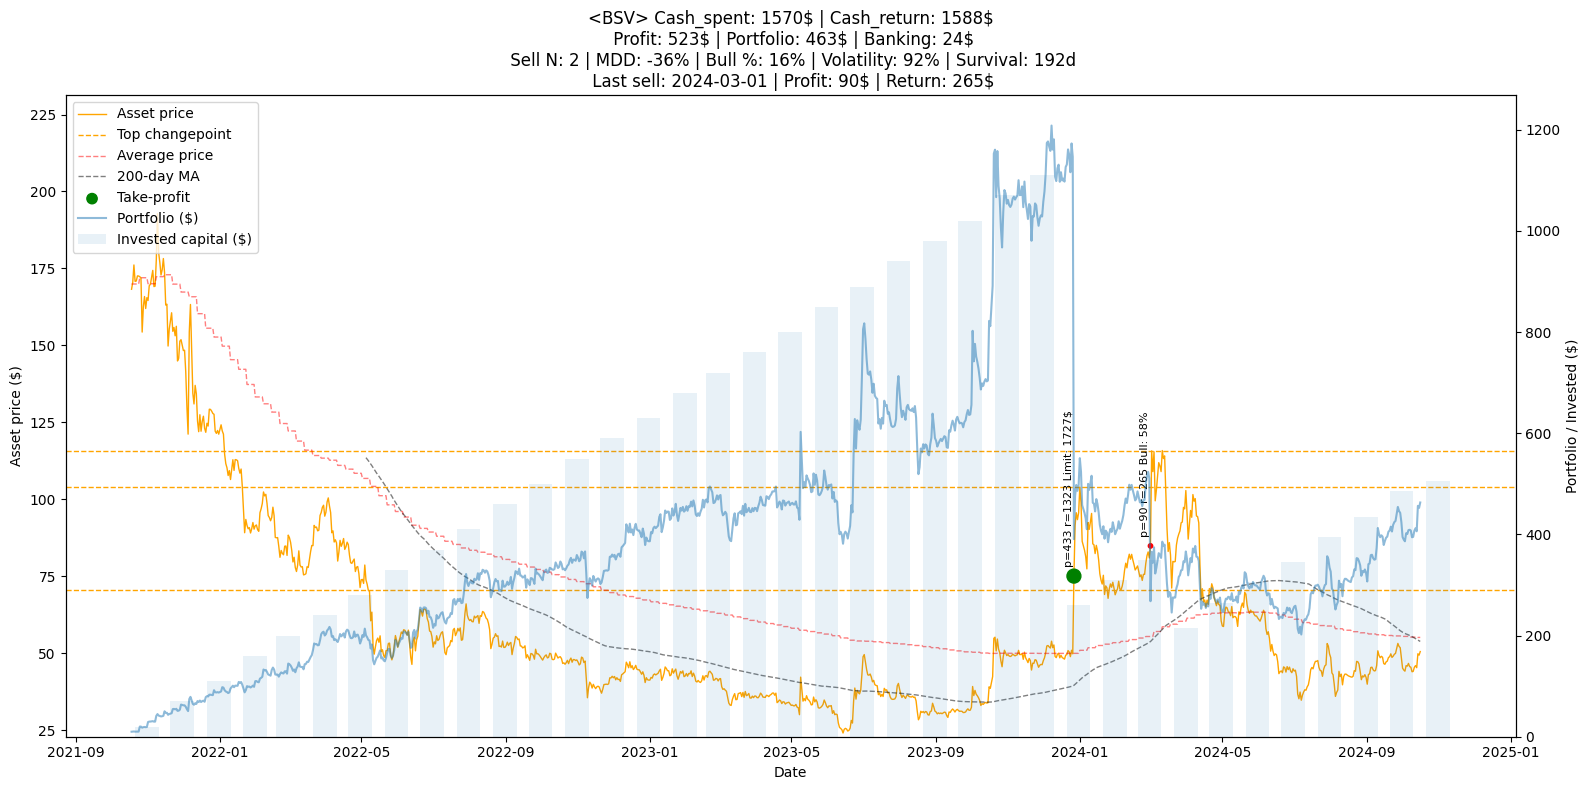

17:25:09 - cmdstanpy - INFO - Chain [1] start processing
17:25:09 - cmdstanpy - INFO - Chain [1] done processing


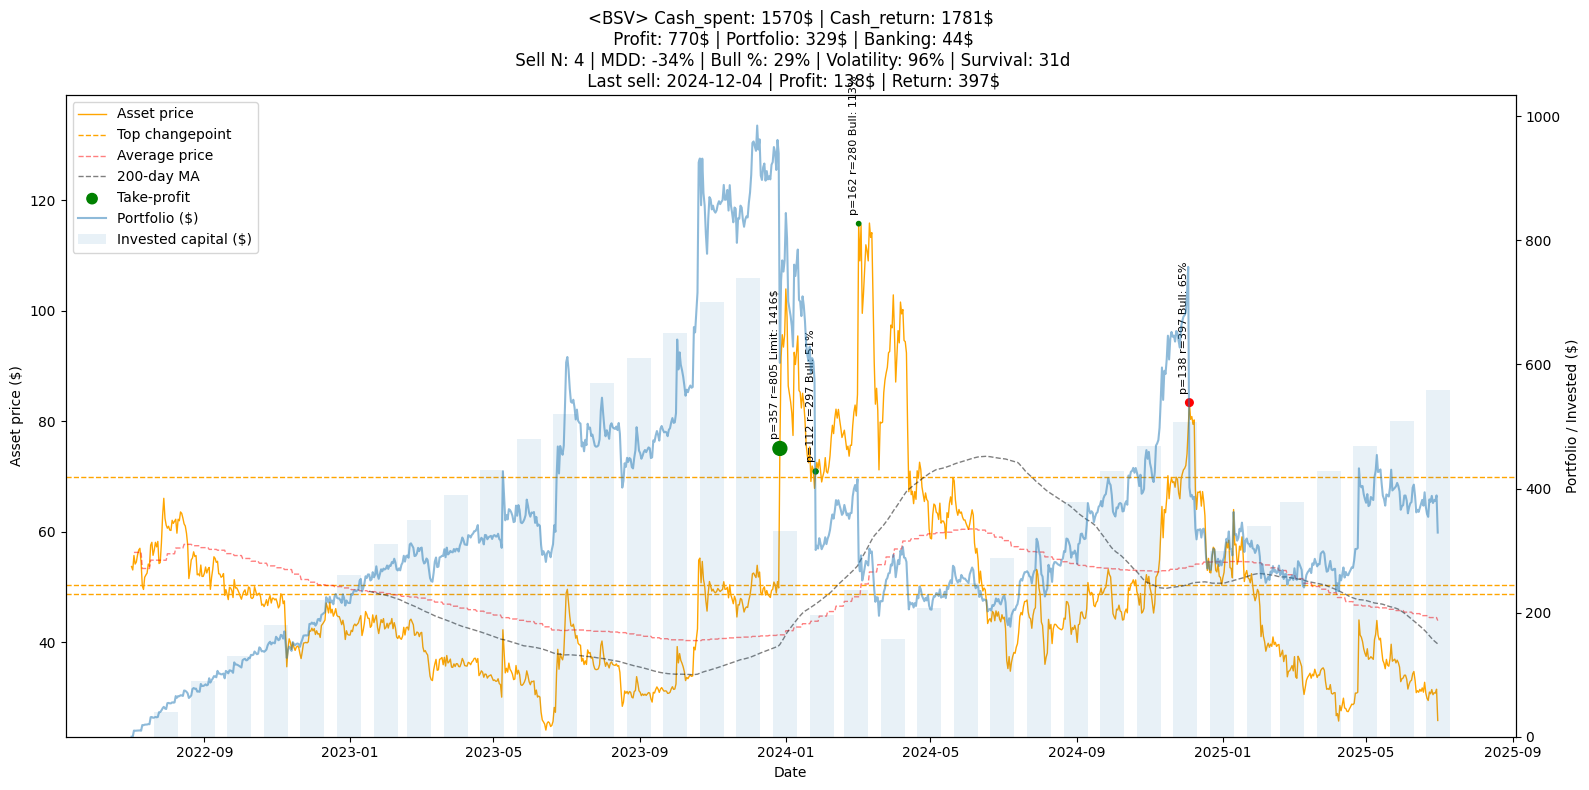

17:25:09 - cmdstanpy - INFO - Chain [1] start processing
17:25:10 - cmdstanpy - INFO - Chain [1] done processing


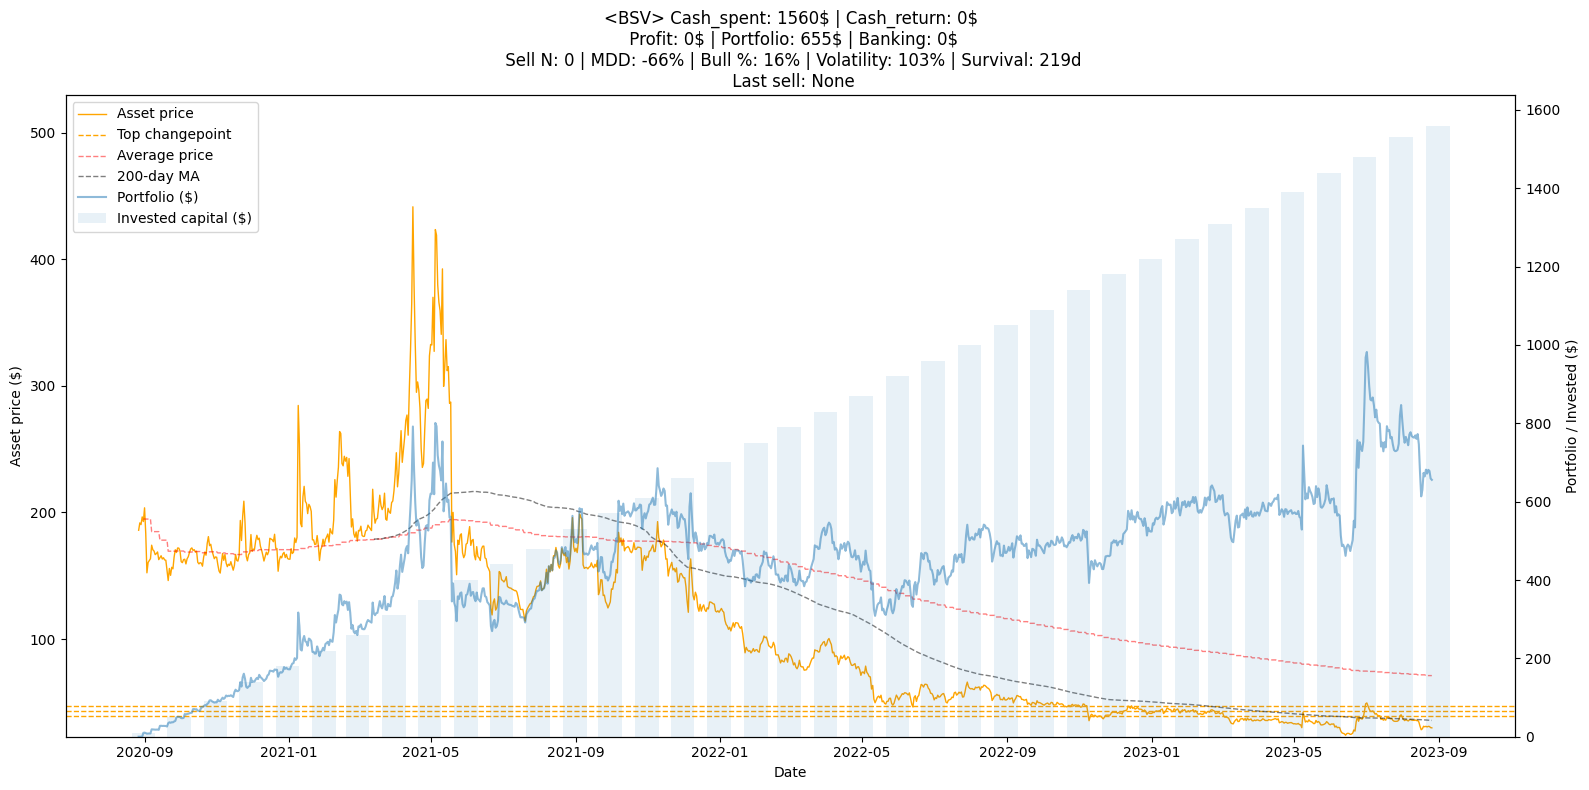

17:25:11 - cmdstanpy - INFO - Chain [1] start processing
17:25:11 - cmdstanpy - INFO - Chain [1] done processing


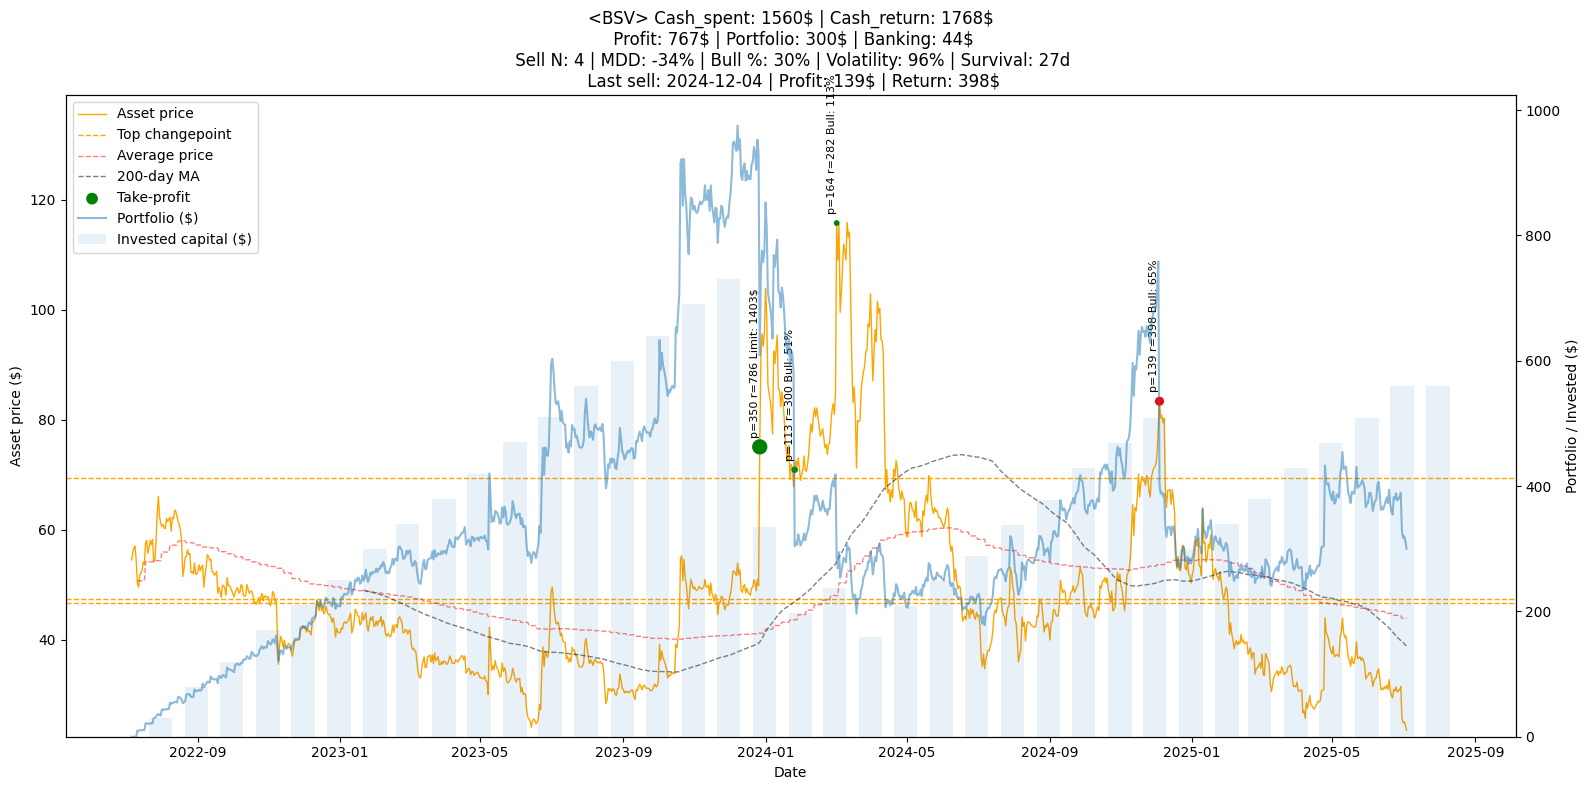

17:25:12 - cmdstanpy - INFO - Chain [1] start processing
17:25:12 - cmdstanpy - INFO - Chain [1] done processing


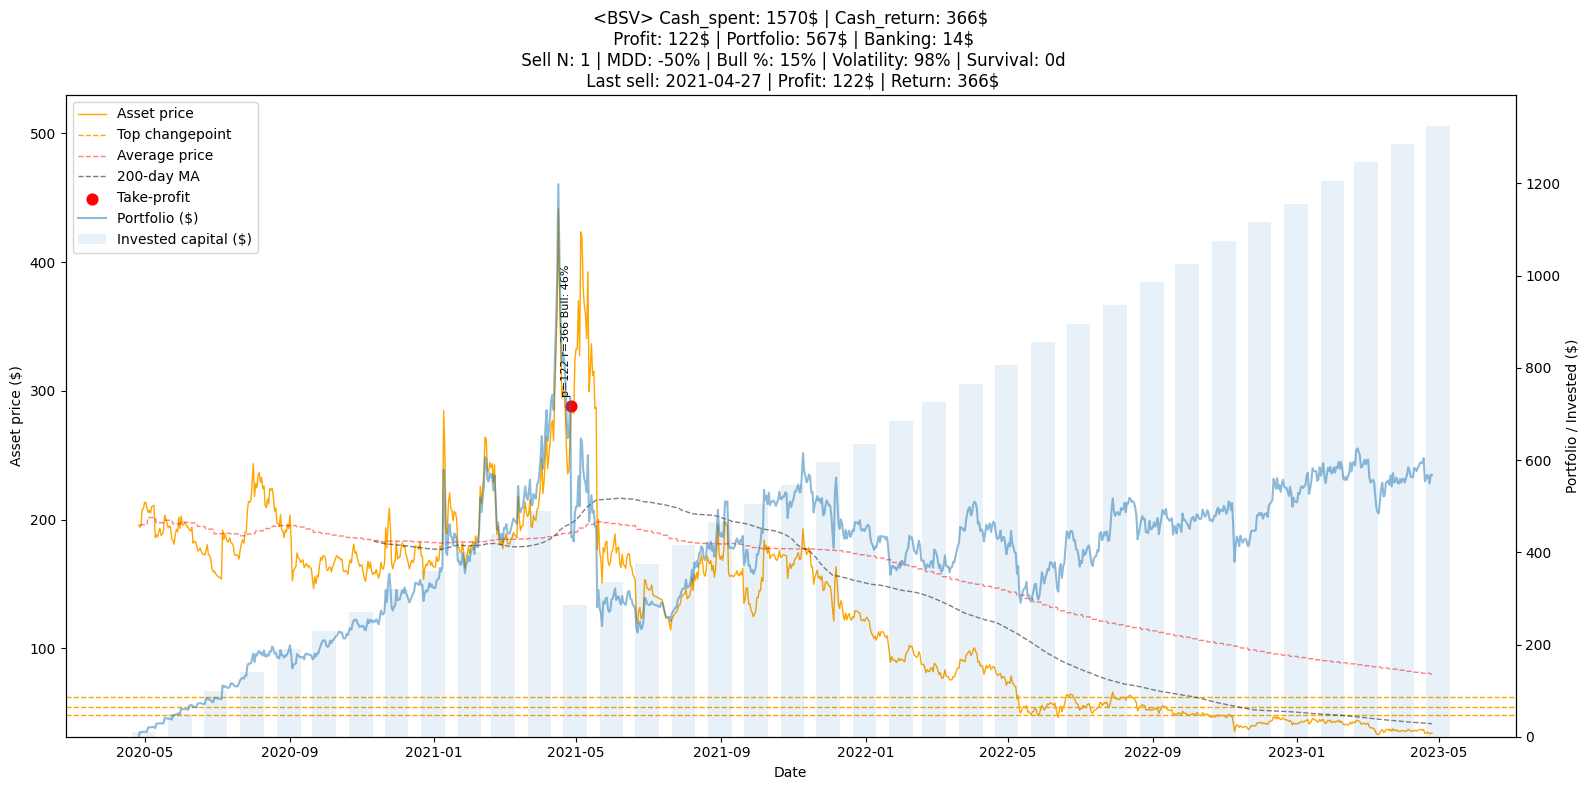

17:25:13 - cmdstanpy - INFO - Chain [1] start processing
17:25:13 - cmdstanpy - INFO - Chain [1] done processing


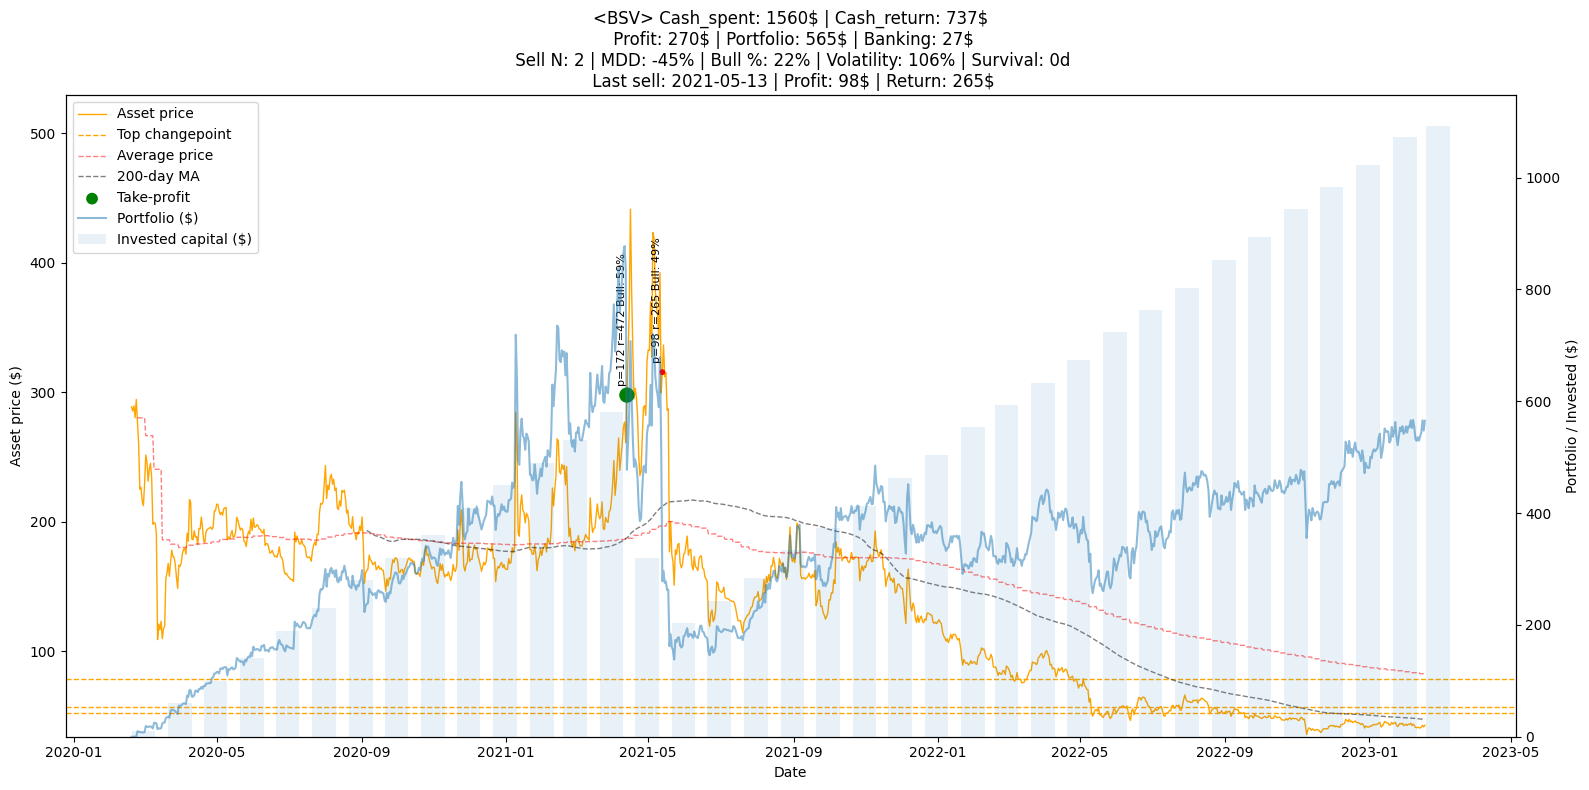

17:25:14 - cmdstanpy - INFO - Chain [1] start processing
17:25:14 - cmdstanpy - INFO - Chain [1] done processing


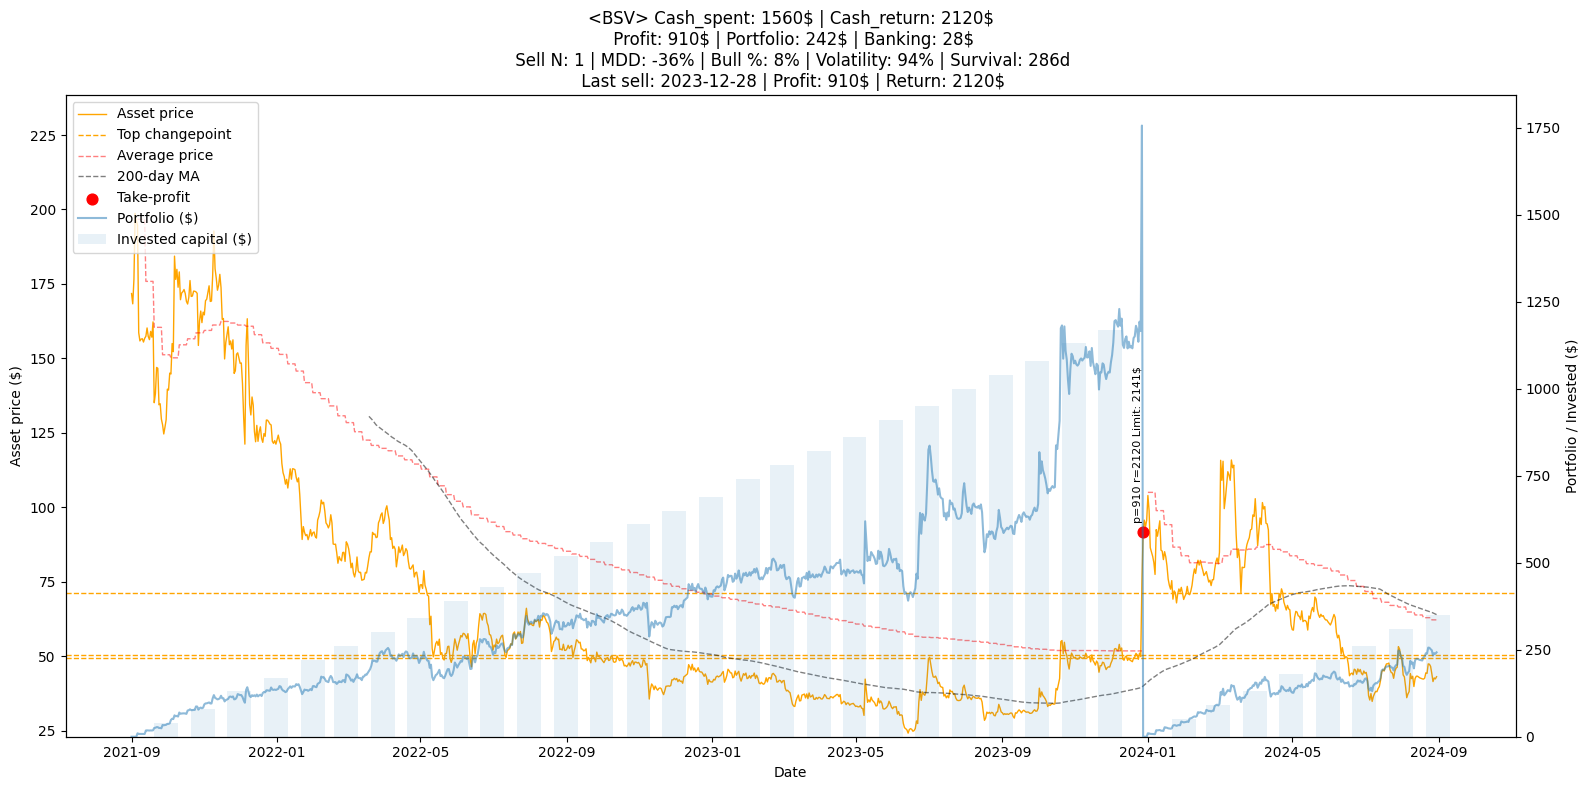

17:25:15 - cmdstanpy - INFO - Chain [1] start processing
17:25:15 - cmdstanpy - INFO - Chain [1] done processing


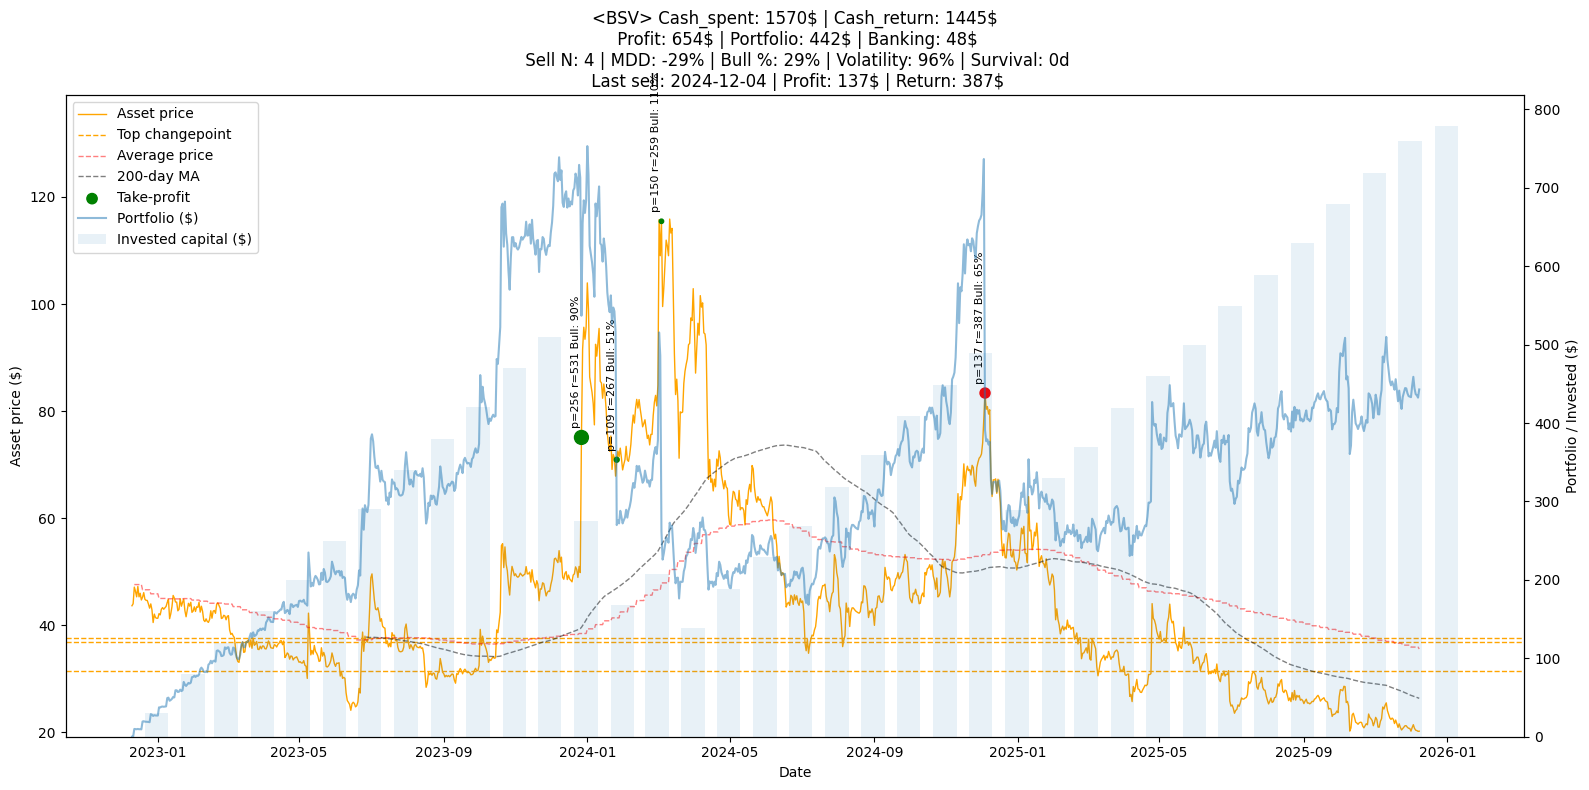

17:25:15 - cmdstanpy - INFO - Chain [1] start processing
17:25:15 - cmdstanpy - INFO - Chain [1] done processing


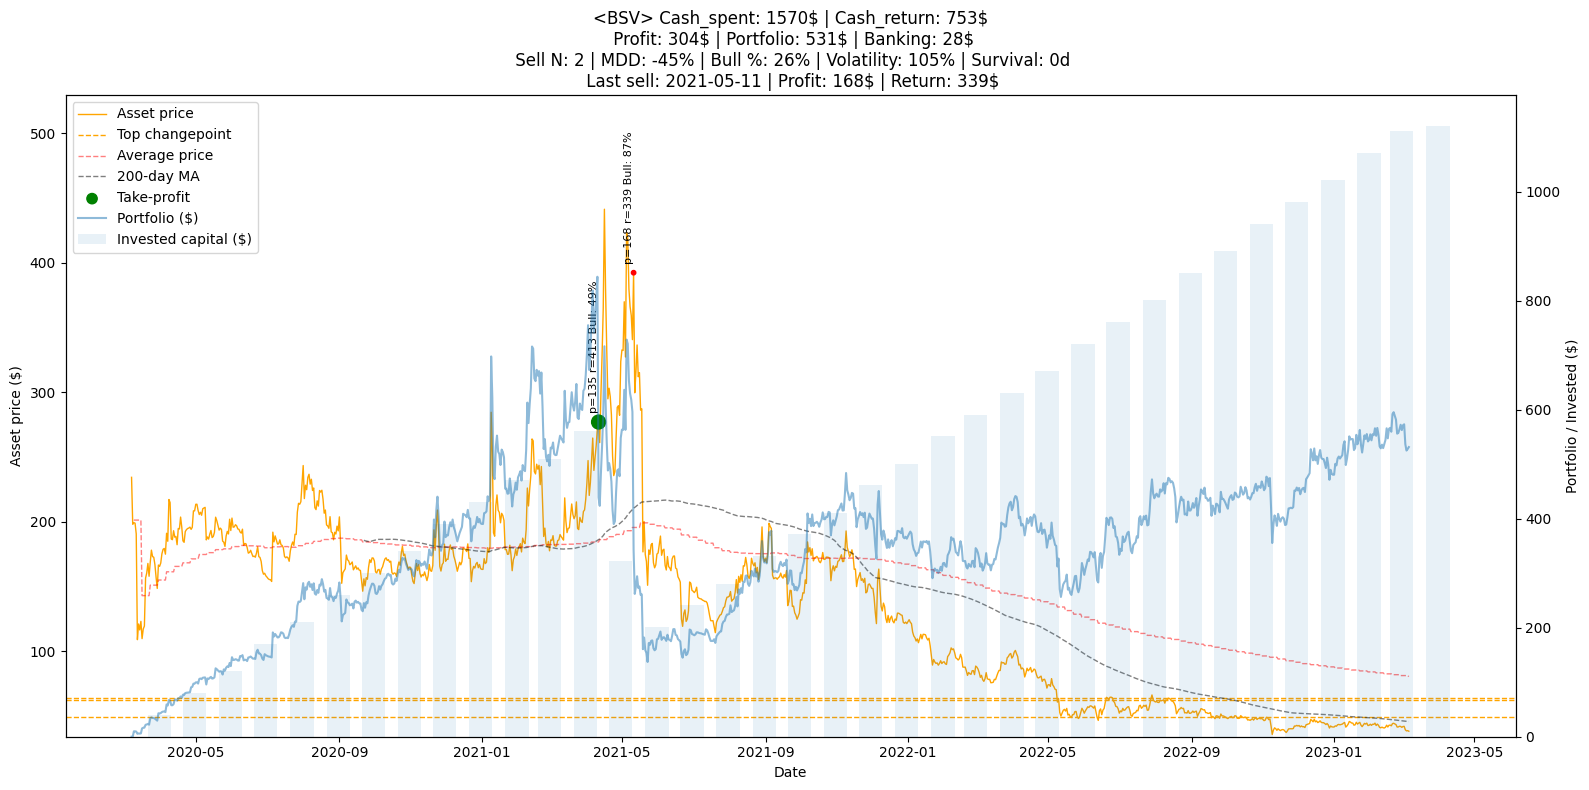

,Target,Cash_spent,Cash_return,Portfolio,Profit,Num_take_profits,Bull_history,MDD,Volatility,Bank_profit,MA200_survival_days,Period,Start,End
0,BSV,1560,0,614,0,0,14,-66,103,0,172.500000,1,2020-08-18,2023-08-17
1,BSV,1570,1588,463,523,2,16,-36,92,24,192.000000,2,2021-10-18,2024-10-16
2,BSV,1570,1781,329,770,4,29,-34,96,44,31.000000,3,2022-07-02,2025-06-30
3,BSV,1560,0,655,0,0,16,-66,103,0,219.333333,4,2020-08-27,2023-08-26
4,BSV,1560,1768,300,767,4,30,-34,96,44,27.000000,5,2022-07-06,2025-07-04
5,BSV,1570,366,567,122,1,15,-50,98,14,0.000000,6,2020-04-26,2023-04-25
6,BSV,1560,737,565,270,2,22,-45,106,27,0.000000,7,2020-02-19,2023-02-17
7,BSV,1560,2120,242,910,1,8,-36,94,28,286.000000,8,2021-09-01,2024-08-30
8,BSV,1570,1445,442,654,4,29,-29,96,48,0.000000,9,2022-12-10,2025-12-08
9,BSV,1570,753,531,304,2,26,-45,105,28,0.000000,10,2020-03-07,2023-03-06


In [7]:
all_metrics = []
last_result = None
last_metrics = None

for p in periods:
    period_prices = p["prices"]

    try:
        bt = BacktestDCA(
        target=target_asset,
        prices=period_prices,
        strategy=strategy
        )
        result, metrics = bt.run()
        ploter(metrics=metrics, history=result)
    except Exception as e:
        print(f"Error backtesting {target_asset} on period {p['period_id']}: {e}")
        continue

    metrics = metrics.copy()
    metrics["Period"] = p["period_id"]
    metrics["Start"] = p["start"]
    metrics["End"] = p["end"]
    all_metrics.append(metrics)

    last_result = result
    last_metrics = metrics

summary = pd.DataFrame(all_metrics)
summary

In [8]:
last_result

,Price,Qty,Cost_basis,Cash_spent,Profit,Returns,Trigger_msg,Portfolio,Average_price
Date,,,,,,,,,
2020-03-07,234.228317,0.000000,0.00000,0.0,0.0,0.0,,0.000000,NaN
2020-03-08,197.949265,0.000000,0.00000,0.0,0.0,0.0,,0.000000,NaN
2020-03-09,199.175552,0.049705,10.00000,10.0,0.0,0.0,,9.900000,201.187427
2020-03-10,198.830719,0.049705,10.00000,10.0,0.0,0.0,,9.882860,201.187427
2020-03-11,190.514709,0.049705,10.00000,10.0,0.0,0.0,,9.469514,201.187427
...,...,...,...,...,...,...,...,...,...
2023-03-02,41.797573,13.708540,1110.97243,1560.0,0.0,0.0,,572.983683,81.042363
2023-03-03,39.139591,13.708540,1110.97243,1560.0,0.0,0.0,,536.546633,81.042363
2023-03-04,38.289860,13.708540,1110.97243,1560.0,0.0,0.0,,524.898056,81.042363


In [9]:
last_metrics

{'Target': 'BSV',
 'Cash_spent': 1570,
 'Cash_return': 753,
 'Portfolio': 531,
 'Profit': 304,
 'Num_take_profits': 2,
 'Bull_history': 26,
 'MDD': -45,
 'Volatility': 105,
 'Bank_profit': 28,
 'MA200_survival_days': 0.0,
 'Period': 10,
 'Start': Timestamp('2020-03-07 00:00:00'),
 'End': Timestamp('2023-03-06 00:00:00')}